In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rcParams.update({'font.size': 14})

import sys
sys.path.insert(0, "synthetic_examples/")
import NOdataset
import Franken_dataset
import Gamma_dataset
import Tukey_dataset
from learn_error_dist import get_data
import pickle

from scipy.stats import laplace_asymmetric
from scipy.stats import gamma
from scipy.stats import norm
from twopiece.scale import *
from twopiece.shape import *
from twopiece.double import *

import torch

In [ ]:
dist="TPG"
dataset="NO_linear_trig"
true_dist=True # we know the true measurement error
x,y,f = get_data(dist, dataset=dataset, N=2000)

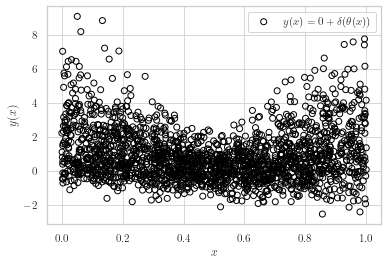

In [ ]:
fig = plt.plot()
plt.scatter(x,y, facecolors='none', edgecolors='black',
            label="$y(x) = 0 + \delta(\\theta(x))$")

plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.legend()
# plt.savefig("../graphs/frankenoutput.pdf")

In [5]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams['figure.figsize'] = [4, 3]
plt.rcParams['figure.dpi'] = 100

In [6]:
# dist="TPG"
# dataset="NO_linear_trig"
np.random.seed(seed=15)
N = 2000
out_dir = "../output_"+dataset+"_"+dist+"/"

var1 = np.loadtxt(out_dir+"var1.txt")
var2 = np.loadtxt(out_dir+"var2.txt")
x_interp = np.loadtxt(out_dir+"inputs.txt")
f_interp=None
x,y,f = get_data(dist, dataset=dataset, N=2000, x=x_interp)
if dataset =="G":
    f_interp = Gdataset.toy_func(x_interp)
else:
    f_interp = np.zeros(len(x_interp))

In [7]:
def get_true_parameters(x, dist, dataset="G"):
    """
    given the distribution and dataset, return the true parameter values for
    the input x
    output:
        var1: list of len(x) (kappa(x) for AL or sigma1(x) for TPG)
        var2: list of len(x) (inverse_lam(x) for AL or sigma2(x) for TPG)
    """
    true_var1=None
    true_var2=None
    if dataset == "G":
        if dist == "AL":
            true_var1 = Gdataset.get_kappa(x)
            true_var2 = Gdataset.get_inverse_lam(x)
        elif dist == "TPG":
            true_var1 = Gdataset.get_sigma1(x)
            true_var2 = Gdataset.get_sigma2(x)
        else:
            raise NameError("Undefined distribution!")
    elif dataset == "NO":
        if dist == "AL":
            true_var1 = NOdataset.get_kappa_linear(x)
            true_var2 = NOdataset.get_inverse_lam_linear(x)
        elif dist == "TPG":
            true_var1 = NOdataset.get_sigma1_linear(x)
            true_var2 = NOdataset.get_sigma2_linear(x)
        else:
            raise NameError("Undefined distribution!")
    elif dataset == "NO_linear_trig":
        if dist == "AL":
            true_var1 = NOdataset.get_kappa_linear(x)
            true_var2 = 1/NOdataset.get_var2_trig(x)
        elif dist == "TPG":
            true_var1 = NOdataset.get_sigma1_linear(x)
            true_var2 = NOdataset.get_var2_trig(x)
    elif dataset == "NO_trig":
            true_var1 = NOdataset.get_var1_trig(x)
            if dist == "AL":
                true_var2 = 1/NOdataset.get_var2_trig(x)
            else:
                true_var2 = NOdataset.get_var2_trig(x)
    elif dataset == "Franken":
        true_var1 = Franken_dataset.get_var1_linear(x)
        true_var2 = 1/Franken_dataset.get_var2_linear(x)
    elif dataset == "Gamma":
        true_var1 = Gamma_dataset.get_var1_trig(x)
        true_var2 = 1/Gamma_dataset.get_var2_trig(x)
    else:   
        raise NameError("Undefined dataset!")
    return true_var1, true_var2

In [8]:
def loadall(filename):
    with open(filename, "rb") as f:
        while True:
            try:
                yield pickle.load(f)
            except EOFError:
                break

In [ ]:
def compare_loss(x, y, all_nets):
    true_var1, true_var2 = get_true_parameters(x, dist, dataset=dataset)
    items = loadall(out_dir+"nets.pkl")
    all_nets = list(items)

    x_test = np.reshape(x, (-1,1))
    # y_test = np.reshape(y, (-1,1))
    x_test = np.float32(x_test)
    y_test = np.float32(y)
    true_all = np.log(np.stack((true_var1, true_var2)).T)
    y_loss = np.stack((y_test, np.zeros(len(x)))).T
    true_accrue = all_nets[0].get_loss(torch.from_numpy(true_all),torch.from_numpy(y_loss))
    pred_accrue=np.zeros(len(all_nets))
    for i in range(len(all_nets)):
        pred_all = all_nets[i].predict(x_test)
        pred_accrue[i] = all_nets[i].get_loss(torch.from_numpy(pred_all),torch.from_numpy(y_loss))
    
    return pred_accrue, true_accrue

In [10]:
# read in all net objects written to nets.pkl
items = loadall(out_dir+"nets.pkl")
all_nets = list(items)
# print(np.shape(all_nets))

# note true_accrue only makes sense for 
if true_dist:
    pred_accrue, true_accrue = compare_loss(x, y, all_nets)
else:
    pred_accrue,_ = compare_loss(x, y_transformed, all_nets)

In [11]:
min_index = np.argmin(pred_accrue)
print("unsorted min index", min_index)
best_net = all_nets[min_index]
print("Best ACCRUE score:", pred_accrue[min_index])

# med_accrue = np.median(pred_accrue)
# print("Median ACCRUE score:", med_accrue)

ind_pred = np.argsort(pred_accrue)
# print(ind_pred)
preds = pred_accrue[ind_pred]
# print(preds)
med_ind = ind_pred[len(pred_accrue)//2]
print("unsorted median index", med_ind)
med_net = all_nets[med_ind]
print("Median ACCRUE score:", pred_accrue[med_ind])

x_test = np.reshape(x_interp, (-1,1))
x_test = np.float32(x_test)
best_preds = np.exp(best_net.predict(x_test))
med_preds = np.exp(med_net.predict(x_test))

unsorted min index 7
Best ACCRUE score: 0.8016029596328735
unsorted median index 9
Median ACCRUE score: 0.8068592548370361


In [12]:
mean_var1 = np.mean(var1, axis=0)
std_var1 = np.std(var1, axis=0)
med_var1 = np.quantile(var1, 0.5, axis=0)
l50_var1 = np.quantile(var1, 0.25, axis=0)
u50_var1 = np.quantile(var1, 0.75, axis=0)
l95_var1 = np.quantile(var1, 0.025, axis=0)
u95_var1 = np.quantile(var1, 0.975, axis=0)
best_var1 = best_preds[:,0]
median_var1 = med_preds[:,0]

mean_var2 = np.mean(var2, axis=0)
std_var2 = np.std(var2, axis=0)
med_var2 = np.quantile(var2, 0.5, axis=0)
l50_var2 = np.quantile(var2, 0.25, axis=0)
u50_var2 = np.quantile(var2, 0.75, axis=0)
l95_var2 = np.quantile(var2, 0.025, axis=0)
u95_var2 = np.quantile(var2, 0.975, axis=0)
best_var2 = best_preds[:,1]
median_var2 = med_preds[:,1]

l90_var1 = np.quantile(var1, 0.05, axis=0)
u90_var1 = np.quantile(var1, 0.95, axis=0)
l90_var2 = np.quantile(var2, 0.05, axis=0)
u90_var2 = np.quantile(var2, 0.95, axis=0)

true_var1, true_var2 = get_true_parameters(x_interp, dist, dataset=dataset)

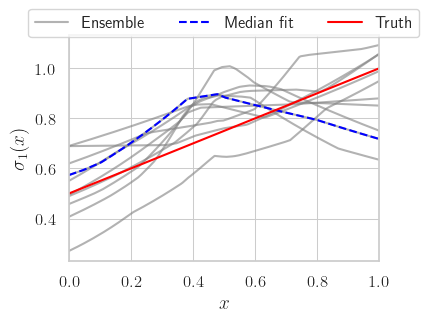

In [13]:
fig = plt.plot()
for i in range(len(var1)-1):
    plt.plot(x_interp,var1[i], c='gray',alpha=0.6)
# plt.plot(x_interp, var1)
# plt.plot(x_interp, true_var1)
plt.plot(x_interp,var1[-1], c='gray',alpha=0.6, label="Ensemble")
# plt.plot(x_interp,best_var1, c='blue',alpha=1.0, linestyle='dashed', label="Best fit")
plt.plot(x_interp,median_var1, c='blue',alpha=1.0, linestyle='dashed', label="Median fit")
if true_dist:
    plt.plot(x_interp,true_var1, c='red', label="Truth")
plt.xlim((0,1))
plt.xlabel("$x$")
if dist == "AL":
    plt.ylabel("$\kappa(x)$")
elif dist == "TPG":
    plt.ylabel("$\sigma_1(x)$")
else:
    plt.ylabel("var1(x)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
        ncol=3, fancybox=True, shadow=False)
plt.savefig(out_dir+dataset+"_"+dist+"_NN_var1_plotall.pdf", bbox_inches="tight")
# plt.close()

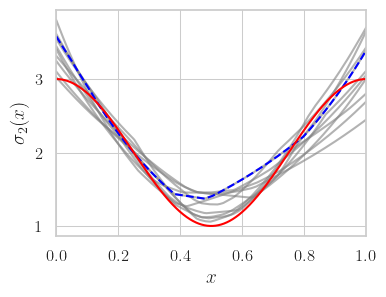

In [14]:
fig = plt.plot()
for i in range(len(var2)):
    plt.plot(x_interp,var2[i], color='gray', alpha=0.6)
# plt.plot(x_interp,best_var2, c='blue',alpha=1.0, linestyle='dashed', label="Best fit")
plt.plot(x_interp,median_var2, c='blue',alpha=1.0, linestyle='dashed', label="Median fit")
if true_dist:
    plt.plot(x_interp,true_var2, c='red', label="True")
plt.xlim((0,1))
plt.xlabel("$x$")
if dist == "AL":
    plt.ylabel("1/$\lambda(x)$")
elif dist == "TPG":
    plt.ylabel("$\sigma_2(x)$")
else:
    plt.ylabel("var2(x)")
plt.savefig(out_dir+dataset+"_"+dist+"_NN_var2_plotall.pdf", bbox_inches="tight")
# plt.close()

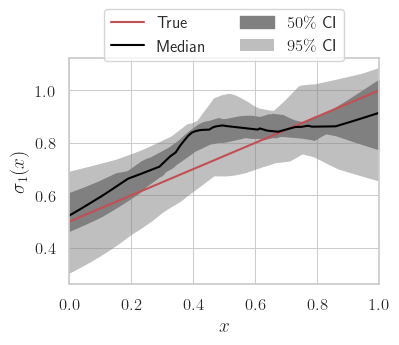

In [15]:
if true_dist:
# if True:
    # plot true vs pred var1 and var2
    fig = plt.plot()
    plt.plot(x_interp,true_var1, c='r', label="True")
    plt.plot(x_interp,med_var1, c='black', label="Median")
    plt.fill_between(x_interp, l50_var1,y2=u50_var1, color='gray',
                    alpha=1.0, label="$50\\%$ CI")
    plt.fill_between(x_interp, l95_var1,y2=u95_var1, color='gray',
                    alpha=0.5, label="$95\\%$ CI",  edgecolor='none')
    # plt.ylim((0,2.5))
    plt.xlim((0,1))
    plt.xlabel("$x$")
    if dist == "AL":
        plt.ylabel("$\kappa(x)$")
    elif dist == "TPG":
        plt.ylabel("$\sigma_1(x)$")
    else:
        plt.ylabel("var1(x)")
    if dataset=="G":
        plt.title("G dataset - Neural Network")
    # plt.legend()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),
          ncol=2, fancybox=True, shadow=False)
    plt.savefig(out_dir+dataset+"_"+dist+"_NN_var1.pdf", bbox_inches="tight")
        # plt.close()

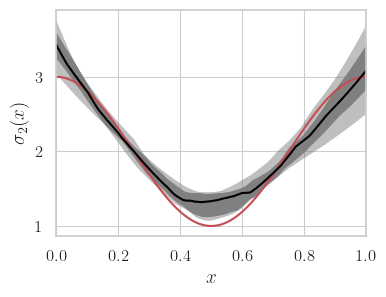

In [16]:
if true_dist:
    fig = plt.plot()
    # plt.plot(x_interp,true_var2, c='black', linestyle='dashed', label="True", zorder=4)
    # plt.plot(x_interp,med_var2, c='blue', label="Median")
    # plt.fill_between(x_interp, l50_var2,y2=u50_var2, color='blue',
    #                 alpha=0.5, label="$50\\%$ CI",edgecolor='none')
    # plt.fill_between(x_interp, l95_var2,y2=u95_var2, color='blue',
    #                 alpha=0.25, label="$95\\%$ CI", edgecolor='none')
    plt.plot(x_interp,true_var2, c='r', label="True")
    plt.plot(x_interp,med_var2, c='black', label="Median")
    plt.fill_between(x_interp, l50_var2,y2=u50_var2, color='gray',
                    alpha=1.0, label="$50\\%$ CI")
    plt.fill_between(x_interp, l95_var2,y2=u95_var2, color='gray',
                    alpha=0.5, label="$95\\%$ CI",  edgecolor='none')
    # plt.ylim((0,2.5))
    plt.xlim((0,1))
    plt.xlabel("$x$")
    if dist == "AL":
        plt.ylabel("1/$\lambda(x)$")
    elif dist == "TPG":
        plt.ylabel("$\sigma_2(x)$")
    else:
        plt.ylabel("var2(x)")
    if dataset=="G":
        plt.title("G dataset - Neural Network")
    # plt.legend()
    plt.savefig(out_dir+dataset+"_"+dist+"_NN_var2.pdf", bbox_inches="tight")
    # plt.close()

In [ ]:
# use median parameters to propagate uncertainty to new replicate
# x,y,_ = get_data(dist, dataset=dataset, N=N)
cis = np.zeros((6, (len(x_interp))))
best_cis = np.zeros((6, (len(x_interp))))
true_cis = np.zeros((6, (len(x_interp))))
if dist == "TPG":
    for i in range(N):
        dist_obj = tpnorm(loc=f_interp[i], sigma1=median_var1[i], sigma2=median_var2[i])
        cis[:,i] = dist_obj.ppf([0.025, 0.25, 0.75, 0.975, 0.05, 0.95])

        dist_obj = tpnorm(loc=f_interp[i], sigma1=best_var1[i], sigma2=best_var2[i])
        best_cis[:,i] = dist_obj.ppf([0.025, 0.25, 0.75, 0.975, 0.05, 0.95])
        if true_dist:
            true_dist_obj = tpnorm(loc=f_interp[i], sigma1=true_var1[i], sigma2=true_var2[i])
            true_cis[:,i] = true_dist_obj.ppf([0.025, 0.25, 0.75, 0.975, 0.05, 0.95])

elif dist == "AL":
    ci50 = laplace_asymmetric.interval(0.5, median_var1, loc=f_interp,
                                        scale=median_var2)
    ci95 = laplace_asymmetric.interval(0.95, median_var1, loc=f_interp,
                                        scale=median_var2)
    ci90 = laplace_asymmetric.interval(0.90, median_var1, loc=f_interp,
                                        scale=median_var2)

    cis[0]=ci95[0]
    cis[3]=ci95[1]
    cis[1]=ci50[0]
    cis[2]=ci50[1]
    cis[4]=ci90[0]
    cis[5]=ci90[1]

    # cis[0]=output_scaler.inverse_transform(np.reshape(ci95[0], (-1, 1))).flatten()
    # cis[3]=output_scaler.inverse_transform(np.reshape(ci95[1], (-1, 1))).flatten()
    # cis[1]=output_scaler.inverse_transform(np.reshape(ci50[0], (-1, 1))).flatten()
    # cis[2]=output_scaler.inverse_transform(np.reshape(ci50[1], (-1, 1))).flatten()

    ci50 = laplace_asymmetric.interval(0.5, best_var1, loc=f_interp,
                                        scale=best_var2)
    ci95 = laplace_asymmetric.interval(0.95, best_var1, loc=f_interp,
                                        scale=best_var2)
    ci90 = laplace_asymmetric.interval(0.90, best_var1, loc=f_interp,
                                        scale=best_var2)
    best_cis[0]=ci95[0]
    best_cis[3]=ci95[1]
    best_cis[1]=ci50[0]
    best_cis[2]=ci50[1]
    best_cis[4]=ci90[0]
    best_cis[5]=ci90[1]

    if true_dist:
        true_ci50 = laplace_asymmetric.interval(0.5, true_var1, loc=f_interp,
                                            scale=true_var2)
        true_ci95 = laplace_asymmetric.interval(0.95, true_var1, loc=f_interp,
                                            scale=true_var2)
        true_ci90 = laplace_asymmetric.interval(0.90, true_var1, loc=f_interp,
                                            scale=true_var2)
        true_cis[0]=true_ci95[0]
        true_cis[3]=true_ci95[1]
        true_cis[1]=true_ci50[0]
        true_cis[2]=true_ci50[1]
        true_cis[4]=true_ci90[0]
        true_cis[5]=true_ci90[1]

        # true_cis[0]=output_scaler.transform(np.reshape(true_ci95[0], (-1, 1))).flatten()
        # true_cis[3]=output_scaler.transform(np.reshape(true_ci95[1], (-1, 1))).flatten()
        # true_cis[1]=output_scaler.transform(np.reshape(true_ci50[0], (-1, 1))).flatten()
        # true_cis[2]=output_scaler.transform(np.reshape(true_ci50[1], (-1, 1))).flatten()
        # true_cis[4]=true_ci90[0]
        # true_cis[5]=true_ci90[1]

if "Franken" in dataset:
    ind1 = np.where(x_interp < 0.33)
    ind2 = np.where(np.logical_and(x_interp <= 0.66,x_interp >= 0.33))
    ind3 = np.where(x_interp > 0.66)
    f1 = f_interp[ind1]
    f2 = f_interp[ind2]
    f3 = f_interp[ind3]
    v1_1 = true_var1[ind1]
    v1_2 = true_var1[ind2]
    v1_3 = true_var1[ind3]
    v2_1 = true_var2[ind1]
    v2_3 = true_var2[ind3]

    gamma_ci50 = gamma.interval(0.5, v1_1, loc=f1,
                                    scale=v2_1)
    gamma_ci90 = gamma.interval(0.90, v1_1, loc=f1,
                                        scale=v2_1)
    gamma_ci95 = gamma.interval(0.95, v1_1, loc=f1,
                                        scale=v2_1)


    norm_ci50 = norm.interval(0.5, loc=f2,scale=v1_2)
    norm_ci90 = norm.interval(0.90, loc=f2,scale=v1_2)
    norm_ci95 = norm.interval(0.95, loc=f2,scale=v1_2)

    neg_ci50 = gamma.interval(0.5, v1_3, loc=f3,
                                        scale=v2_3)
    neg_ci90 = gamma.interval(0.90, v1_3, loc=f3,
                                        scale=v2_3)
    neg_ci95 = gamma.interval(0.90, v1_3, loc=f3,
                                scale=v2_3)

    true_cis[1]=np.concatenate((gamma_ci50[0], norm_ci50[0], -neg_ci50[0]))
    true_cis[2]=np.concatenate((gamma_ci50[1], norm_ci50[1], -neg_ci50[1]))
    true_cis[4]=np.concatenate((gamma_ci90[0], norm_ci90[0], -neg_ci90[0]))
    true_cis[5]=np.concatenate((gamma_ci90[1], norm_ci90[1], -neg_ci90[1]))
    true_cis[0]=np.concatenate((gamma_ci95[0], norm_ci95[0], -neg_ci95[0]))
    true_cis[3]=np.concatenate((gamma_ci95[1], norm_ci95[1], -neg_ci95[1]))

elif "Gamma" in dataset:
        ind1 = np.where(x_interp < 0.33)
        ind2 = np.where(np.logical_and(x_interp <= 0.66,x_interp >= 0.33))
        ind3 = np.where(x_interp > 0.66)
        f1 = f_interp[ind1]
        f2 = f_interp[ind2]
        f3 = f_interp[ind3]
        v1_1 = true_var1[ind1]
        v1_2 = true_var1[ind2]
        v1_3 = true_var1[ind3]
        v2_1 = true_var2[ind1]
        v2_3 = true_var2[ind3]

        true_ci50 = gamma.interval(0.5, true_var1, loc=f_interp,
                                        scale=true_var2)
        true_ci90 = gamma.interval(0.9, true_var1, loc=f_interp,
                                        scale=true_var2)
        true_ci95 = gamma.interval(0.95, true_var1, loc=f_interp,
                                        scale=true_var2)

        true_cis[0]=-1*true_ci95[0]
        true_cis[3]=-1*true_ci95[1]
        true_cis[1]=-1*true_ci50[0]
        true_cis[2]=-1*true_ci50[1]
        true_cis[4]=-1*true_ci90[0]
        true_cis[5]=-1*true_ci90[1]

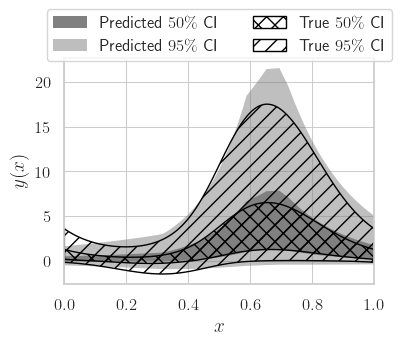

In [17]:
fig = plt.plot()

plt.fill_between(x_interp, cis[1],y2=cis[2], color='gray', alpha=1.0,
                label="Predicted $50\\%$ CI", edgecolor='none')
plt.fill_between(x_interp, cis[0],y2=cis[3], color='gray', alpha=0.5,
                label="Predicted $95\\%$ CI", edgecolor='none')
plt.fill_between(x_interp, true_cis[1],y2=true_cis[2], color='none',
                label="True $50\\%$ CI", hatch='XX', edgecolor='black')
plt.fill_between(x_interp, true_cis[0],y2=true_cis[3], color='none',
                label="True $95\\%$ CI", hatch='//', edgecolor='black')

plt.xlim((0,1))
plt.xlabel("$x$")
plt.ylabel("$y(x)$")
# plt.legend(loc="upper right")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),
          ncol=2, fancybox=True, shadow=False)
# plt.legend()
if dataset=="G":
    plt.title("G dataset - Error Distribution Confidence Intervals")
plt.savefig(out_dir+dataset+"_"+dist+"_CI_comparison.pdf", bbox_inches="tight")